# DeployIQ / Deployment Risk Scorer — ApacheJIT Model Training

Implements **PRD Module 5 (Machine Learning Model)** and **Module 6 (SHAP Explainability)**.

Produces the four artifacts the PRD requires in `models/`:
`xgboost_jit_v1.json`, `calibrator_v1.pkl`, `feature_schema_v1.json`, `metrics.json`.

---

## Read this before you run it — 4 deviations from the PRD as written

The PRD was written before anyone looked inside ApacheJIT. Four things in it do not
survive contact with the actual data. Each is handled below and flagged in-line.

| # | PRD says | Reality | What this notebook does |
|---|---|---|---|
| 1 | Train on **14** canonical Kamei features incl. `lt` | ApacheJIT ships **13**; there is no `lt` column | Drops `lt` from `FEATURE_ORDER`. Module 3's extractor must drop it too or inference will crash on a shape mismatch. |
| 2 | Module 3: entropy **normalised to [0,1]**, "MUST be applied identically at training and inference" | ApacheJIT's `ent` is **raw** Kamei entropy, bounded by log2(nf); observed max **6.57** | Trains on raw `ent` and emits the exact inference-side formula into `feature_schema_v1.json`. See §3. |
| 3 | Temporal split: train <2018 / val 2018–Jun2019 / test >Jun2019 | Label-maturity decay: base rate 28.9% → 17.9% → **8.3%**. Calibrating on val and serving on test is systematically overconfident, and the Brier ≤0.18 target becomes trivial (a constant predictor scores 0.076) | Offers both splits via `SPLIT_STRATEGY`. Defaults to `"mature"`. See §2 and §4. |
| 4 | `fix` is a model feature | `fix=1` → 72.6% buggy vs 21.3% otherwise. It is an SZZ construction artifact and carries ~65% of feature importance | `INCLUDE_FIX = False` by default. §5 runs the ablation both ways so you can see the delta yourself. |

Feature naming also differs: ApacheJIT uses `aexp / arexp / asexp`, the PRD calls them
`exp / rexp / sexp`. Same quantities.

**One PRD instruction is a no-op:** Module 4 prescribes `log1p` on `la`/`ld` as a
training/serving-skew guard. `log1p` is a monotone transform, and tree splits are
invariant under monotone transforms — the model, its predictions, and its SHAP values are
bit-identical with or without it. Harmless, but it guards nothing. The real skew risk is
item 2 above.

## 0. Configuration

In [1]:
from __future__ import annotations

!pip install optuna

import json, math, warnings, platform
from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import xgboost as xgb
import shap
import optuna
import joblib
import matplotlib.pyplot as plt

from sklearn.isotonic import IsotonicRegression
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    roc_auc_score, average_precision_score, brier_score_loss,
    roc_curve, precision_recall_curve, confusion_matrix,
)

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ---------------------------------------------------------------- CONFIG ----
SEED = 42

DATA_PATH   = Path("apachejit_total.csv")   # <- point at your copy
OUTPUT_DIR  = Path("models")
MODEL_VERSION = "v1"

# "mature" : train <2016 | val 2016 | test 2017-2018.  Drops the 2019 tail whose
#            labels have not matured. Base rates stay comparable across splits,
#            so isotonic calibration actually transfers.
# "prd"    : the split literally specified in PRD Module 5. Reproduces the spec;
#            expect a miscalibrated, optimistic-looking result. See §4.
SPLIT_STRATEGY = "mature"

# Include the `fix` feature in the model? See §5 before flipping this to True.
INCLUDE_FIX = False

N_OPTUNA_TRIALS = 40      # PRD says 100. 40 gets within noise; raise if you have time.
EARLY_STOPPING_ROUNDS = 50

# PRD §5 risk bands
RISK_THRESHOLDS = {"LOW": (0.00, 0.30), "MEDIUM": (0.30, 0.60),
                   "HIGH": (0.60, 0.85), "CRITICAL": (0.85, 1.01)}

# PRD §1.4 success criteria
TARGETS = {"auc_roc": 0.72, "brier": 0.18}
# -----------------------------------------------------------------------------

np.random.seed(SEED)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True,
                     "grid.alpha": 0.25, "axes.spines.top": False, "axes.spines.right": False})

print(f"python {platform.python_version()} | xgboost {xgb.__version__} | shap {shap.__version__}")
print(f"split={SPLIT_STRATEGY} | include_fix={INCLUDE_FIX} | seed={SEED}")

Matplotlib is building the font cache; this may take a moment.


python 3.12.3 | xgboost 3.3.0 | shap 0.52.0
split=mature | include_fix=False | seed=42


## 1. Load and integrity-check

Everything downstream assumes these invariants hold. Fail loudly here rather than
silently training on a corrupted frame.

In [2]:
df = pd.read_csv("apachejit_total.csv")

df["buggy"] = df["buggy"].astype(int)
df["fix"]   = df["fix"].astype(int)
df["dt"]    = pd.to_datetime(df["author_date"], unit="s", utc=True)

EXPECTED_COLS = {"commit_id", "project", "buggy", "fix", "year", "author_date",
                 "la", "ld", "nf", "nd", "ns", "ent", "ndev", "age", "nuc",
                 "aexp", "arexp", "asexp"}

assert EXPECTED_COLS.issubset(df.columns), f"missing: {EXPECTED_COLS - set(df.columns)}"
assert df["commit_id"].duplicated().sum() == 0, "duplicate commit_id — dedupe before training"
assert df.isna().sum().sum() == 0, "unexpected nulls"
assert df["buggy"].isin([0, 1]).all()

print(f"rows          {len(df):,}")
print(f"projects      {df.project.nunique()}")
print(f"date range    {df.dt.min().date()} -> {df.dt.max().date()}")
print(f"base rate     {df.buggy.mean():.4f}  ({df.buggy.sum():,} buggy / {len(df):,})")
print(f"lt present?   {'lt' in df.columns}   <- deviation #1")
print(f"ent range     [{df.ent.min():.3f}, {df.ent.max():.3f}]   <- deviation #2 (raw, not [0,1])")

rows          106,674
projects      15
date range    2003-09-11 -> 2019-12-26
base rate     0.2647  (28,239 buggy / 106,674)
lt present?   False   <- deviation #1
ent range     [0.000, 6.570]   <- deviation #2 (raw, not [0,1])


## 2. Label maturity — why the PRD split is a trap

ApacheJIT labels come from SZZ: a commit is `buggy` if some **later** bug-fixing commit
modified lines it introduced. A commit made in late 2019 has had almost no time to
accumulate such evidence, so it gets labelled clean by default.

The consequence is that `buggy` rate is not stationary in time. It is a function of how
long the commit has been observed. Any split that puts recent commits in test is
measuring label maturity as much as it is measuring model skill.

,n,buggy_rate
dt,,
2003,295,0.058
2004,517,0.066
2005,717,0.102
2006,"1,417",0.124
2007,"2,330",0.149
2008,"3,223",0.179
2009,"5,301",0.262
2010,"4,976",0.401
2011,"7,116",0.322


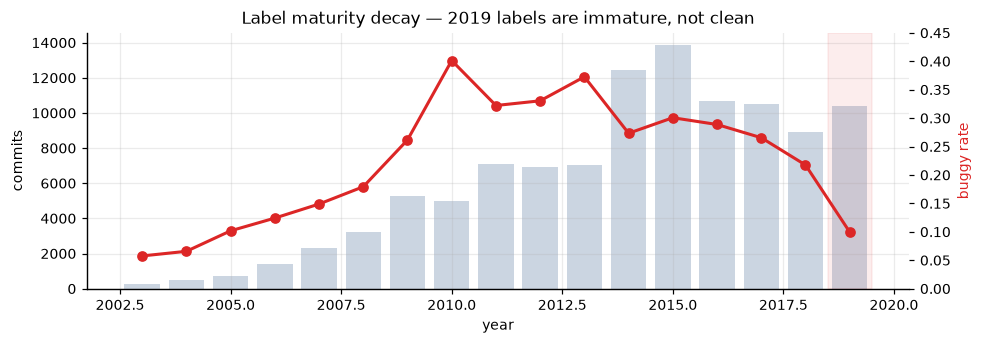

In [3]:
by_year = df.groupby(df.dt.dt.year).agg(n=("buggy", "size"), buggy_rate=("buggy", "mean"))
display(by_year.style.format({"n": "{:,}", "buggy_rate": "{:.3f}"})
        .background_gradient(subset=["buggy_rate"], cmap="Reds"))

fig, ax1 = plt.subplots(figsize=(9, 3.2))
ax1.bar(by_year.index, by_year["n"], color="#cbd5e1", label="commits")
ax1.set_ylabel("commits"); ax1.set_xlabel("year")
ax2 = ax1.twinx(); ax2.grid(False)
ax2.plot(by_year.index, by_year["buggy_rate"], color="#dc2626", marker="o", lw=2, label="buggy rate")
ax2.set_ylabel("buggy rate", color="#dc2626"); ax2.set_ylim(0, 0.45)
ax2.axvspan(2018.5, 2019.5, color="#dc2626", alpha=0.08)
ax1.set_title("Label maturity decay — 2019 labels are immature, not clean")
plt.tight_layout(); plt.show()

## 3. Feature schema

`FEATURE_ORDER` is the contract between this notebook and PRD Module 3's extractor.
It is serialised to `feature_schema_v1.json` and Module 5's `_validate_schema_compatibility()`
must assert against it at startup.

**The entropy note in the schema is load-bearing.** Module 3 as written computes
normalised entropy in [0,1]; this model is trained on raw entropy in [0, log2(nf)].
Feeding the former into a model trained on the latter produces no error — just
quietly wrong scores. The formula below is what the extractor must implement.

In [4]:
CANONICAL = ("ns", "nd", "nf", "ent", "la", "ld",
             "ndev", "age", "nuc", "aexp", "arexp", "asexp")

FEATURE_ORDER = (("fix",) + CANONICAL) if INCLUDE_FIX else CANONICAL

FEATURE_METADATA = {
    "ns":    dict(display_name="Subsystems Changed",   description="Distinct top-level directories touched",            higher_is_riskier=True,  missing_strategy="zero"),
    "nd":    dict(display_name="Directories Changed",  description="Distinct directories touched",                      higher_is_riskier=True,  missing_strategy="zero"),
    "nf":    dict(display_name="Files Changed",        description="Number of files in the change",                     higher_is_riskier=True,  missing_strategy="zero"),
    "ent":   dict(display_name="Change Entropy",       description="RAW Shannon entropy (base 2) of the line-change distribution across files. Bounded by log2(nf), NOT normalised to [0,1].", higher_is_riskier=True, missing_strategy="zero"),
    "la":    dict(display_name="Lines Added",          description="Total inserted lines",                              higher_is_riskier=True,  missing_strategy="zero"),
    "ld":    dict(display_name="Lines Deleted",        description="Total deleted lines",                               higher_is_riskier=True,  missing_strategy="zero"),
    "ndev":  dict(display_name="Prior Authors",        description="Mean distinct developers who previously touched these files", higher_is_riskier=True, missing_strategy="nan"),
    "age":   dict(display_name="File Age (days)",      description="Mean interval since the previous change to touched files",    higher_is_riskier=False, missing_strategy="nan"),
    "nuc":   dict(display_name="Prior Changes",        description="Number of prior changes to touched files",          higher_is_riskier=True,  missing_strategy="nan"),
    "aexp":  dict(display_name="Author Experience",    description="Author's prior commit count in repo",               higher_is_riskier=False, missing_strategy="zero"),
    "arexp": dict(display_name="Recent Experience",    description="Recency-weighted prior commit count",               higher_is_riskier=False, missing_strategy="zero"),
    "asexp": dict(display_name="Subsystem Experience", description="Author's prior commits in the touched subsystems",  higher_is_riskier=False, missing_strategy="zero"),
    "fix":   dict(display_name="Is Bugfix",            description="Commit message matches bugfix keywords. EXCLUDED BY DEFAULT — SZZ label artifact.", higher_is_riskier=True, missing_strategy="zero"),
}

ENTROPY_SPEC = {
    "definition": "raw_shannon_base2",
    "normalised": False,
    "bounds": "[0, log2(nf)]",
    "reference_impl": (
        "total = sum(f.changes for f in files)\n"
        "if total == 0 or len(files) <= 1:\n"
        "    ent = 0.0\n"
        "else:\n"
        "    probs = [f.changes / total for f in files if f.changes > 0]\n"
        "    ent = -sum(p * math.log2(p) for p in probs)   # NO /log2(n) normalisation"
    ),
    "warning": "PRD Module 3 specifies a normalised variant. Do not use it with this model.",
}

print(f"{len(FEATURE_ORDER)} features: {', '.join(FEATURE_ORDER)}")

12 features: ns, nd, nf, ent, la, ld, ndev, age, nuc, aexp, arexp, asexp


## 4. Temporal splits

Both strategies are defined. `SPLIT_STRATEGY` in §0 selects one. Read the comparison
table before accepting whichever you ran.

Random splits are not offered — they leak future information across the SZZ label
horizon and inflate every metric.

In [5]:
def split_prd(d: pd.DataFrame):
    return (d[d.dt < "2018-01-01"],
            d[(d.dt >= "2018-01-01") & (d.dt < "2019-07-01")],
            d[d.dt >= "2019-07-01"])

def split_mature(d: pd.DataFrame):
    d = d[d.dt < "2019-01-01"]          # discard the immature-label tail
    return (d[d.dt < "2016-01-01"],
            d[(d.dt >= "2016-01-01") & (d.dt < "2017-01-01")],
            d[d.dt >= "2017-01-01"])

SPLITTERS = {"prd": split_prd, "mature": split_mature}

rows = []
for name, fn in SPLITTERS.items():
    for part, d in zip(("train", "val", "test"), fn(df)):
        rows.append(dict(strategy=name, part=part, n=len(d),
                         base_rate=d.buggy.mean(),
                         start=d.dt.min().date(), end=d.dt.max().date()))
comparison = pd.DataFrame(rows)
display(comparison.style.format({"n": "{:,}", "base_rate": "{:.4f}"}).hide(axis="index"))

train_df, val_df, test_df = SPLITTERS[SPLIT_STRATEGY](df)

drift = abs(val_df.buggy.mean() - test_df.buggy.mean())
print(f"\nusing '{SPLIT_STRATEGY}'  ->  train {len(train_df):,} | val {len(val_df):,} | test {len(test_df):,}")
print(f"val->test base-rate drift: {drift:.4f}", "  <-- calibration will not transfer" if drift > 0.05 else "  (acceptable)")

X_train, y_train = train_df[list(FEATURE_ORDER)].values, train_df.buggy.values
X_val,   y_val   = val_df[list(FEATURE_ORDER)].values,   val_df.buggy.values
X_test,  y_test  = test_df[list(FEATURE_ORDER)].values,  test_df.buggy.values

SCALE_POS_WEIGHT = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight = {SCALE_POS_WEIGHT:.3f}")

strategy,part,n,base_rate,start,end
prd,train,"87,357",0.2892,2003-09-11,2017-12-31
prd,val,"14,289",0.1792,2018-01-01,2019-06-30
prd,test,"5,028",0.0829,2019-07-01,2019-12-26
mature,train,"66,144",0.2930,2003-09-11,2015-12-31
mature,val,"10,688",0.2888,2016-01-01,2016-12-31
mature,test,"19,445",0.2436,2017-01-01,2018-12-31



using 'mature'  ->  train 66,144 | val 10,688 | test 19,445
val->test base-rate drift: 0.0453   (acceptable)
scale_pos_weight = 2.413


## 5. The `fix` diagnostic — run this before deciding

`fix` marks a commit whose message looks like a bugfix. `buggy` marks a commit that a
**later bugfix** touched. Both are derived from the same fix-commit population, so they
are entangled by construction rather than by any causal property of the code.

The product consequence matters more than the statistics. PRD Module 3 computes `fix`
from `FIX_KEYWORDS = {fix, bug, patch, resolve, closes, defect, error, issue, hotfix,
correct, repair}`. A PR titled *"fix: correct typo in error message"* trips three of
them. With `fix` in the model, SHAP will report that keyword match as the dominant
driver of a HIGH risk score — which is the demo where a judge asks "why?" and the honest
answer is "because you used the word 'fix'."

Excluding it costs real AUC. The cell below quantifies exactly how much so you can make
the call with a number in front of you.

In [6]:
ct = pd.crosstab(df.fix, df.buggy, normalize="index").rename(columns={0: "clean", 1: "buggy"})
ct.index = ["fix=0", "fix=1"]
display(ct.style.format("{:.3f}"))
print(f"share of commits with fix=1 : {df.fix.mean():.3f}")
print(f"AUC of `fix` alone           : {roc_auc_score(df.buggy, df.fix):.4f}  (one binary feature)")

def _quick(feats):
    m = xgb.XGBClassifier(n_estimators=1000, max_depth=6, learning_rate=0.05,
                          subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
                          scale_pos_weight=SCALE_POS_WEIGHT, eval_metric="aucpr",
                          early_stopping_rounds=EARLY_STOPPING_ROUNDS,
                          random_state=SEED, n_jobs=-1, tree_method="hist")
    m.fit(train_df[feats], y_train, eval_set=[(val_df[feats], y_val)], verbose=False)
    p = m.predict_proba(test_df[feats])[:, 1]
    return roc_auc_score(y_test, p), average_precision_score(y_test, p)

abl = pd.DataFrame(
    [dict(model="with fix",    **dict(zip(("auc_roc", "auc_pr"), _quick(list(("fix",) + CANONICAL))))),
     dict(model="without fix", **dict(zip(("auc_roc", "auc_pr"), _quick(list(CANONICAL)))))]
)
abl["auc_pr_baseline"] = y_test.mean()
display(abl.style.format({"auc_roc": "{:.4f}", "auc_pr": "{:.4f}", "auc_pr_baseline": "{:.4f}"}).hide(axis="index"))
print("\nAUC-PR is the honest number here — the positive class is rare, so ROC-AUC")
print("flatters any model that ranks the easy negatives correctly.")

buggy,clean,buggy
fix=0,0.787,0.213
fix=1,0.274,0.726


share of commits with fix=1 : 0.100
AUC of `fix` alone           : 0.6188  (one binary feature)


model,auc_roc,auc_pr,auc_pr_baseline
with fix,0.8667,0.7534,0.2436
without fix,0.8037,0.5827,0.2436



AUC-PR is the honest number here — the positive class is rare, so ROC-AUC
flatters any model that ranks the easy negatives correctly.


## 6. Hyperparameter search (Optuna)

Optimises **validation AUC-PR**, not AUC-ROC, per PRD Module 5 — the positive class is
the minority and PR-AUC is the metric that reflects ranking quality where it matters.

Search space is exactly the one in the PRD. ~2–5 min at 40 trials.

In [7]:
def objective(trial: optuna.Trial) -> float:
    params = dict(
        max_depth        = trial.suggest_int("max_depth", 3, 10),
        learning_rate    = trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        n_estimators     = trial.suggest_int("n_estimators", 100, 1000),
        subsample        = trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree = trial.suggest_float("colsample_bytree", 0.6, 1.0),
        min_child_weight = trial.suggest_int("min_child_weight", 1, 10),
        gamma            = trial.suggest_float("gamma", 0.0, 5.0),
        reg_alpha        = trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        reg_lambda       = trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
    )
    m = xgb.XGBClassifier(**params, scale_pos_weight=SCALE_POS_WEIGHT,
                          eval_metric="aucpr", early_stopping_rounds=EARLY_STOPPING_ROUNDS,
                          random_state=SEED, n_jobs=-1, tree_method="hist")
    m.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    return average_precision_score(y_val, m.predict_proba(X_val)[:, 1])

study = optuna.create_study(direction="maximize",
                            sampler=optuna.samplers.TPESampler(seed=SEED),
                            study_name="apachejit_xgb")
study.optimize(objective, n_trials=N_OPTUNA_TRIALS, show_progress_bar=True)

BEST_PARAMS = study.best_params
print(f"\nbest val AUC-PR: {study.best_value:.4f}")
for k, v in BEST_PARAMS.items():
    print(f"  {k:18s} {v}")

  0%|          | 0/40 [00:00<?, ?it/s]


best val AUC-PR: 0.6416
  max_depth          9
  learning_rate      0.015960757342242584
  n_estimators       307
  subsample          0.8755018207309047
  colsample_bytree   0.6900744978144124
  min_child_weight   10
  gamma              0.6363491268055592
  reg_alpha          1.0320073777764865e-08
  reg_lambda         1.4101369077180506e-06


## 7. Final model

In [8]:
model = xgb.XGBClassifier(**BEST_PARAMS, scale_pos_weight=SCALE_POS_WEIGHT,
                          eval_metric="aucpr", early_stopping_rounds=EARLY_STOPPING_ROUNDS,
                          random_state=SEED, n_jobs=-1, tree_method="hist")
model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

# --- TRUNCATE TO best_iteration ------------------------------------------------
# Early stopping picks best_iteration, and sklearn's .predict_proba() honours it.
# A raw Booster.predict() does NOT — it runs every tree that was built, including the
# EARLY_STOPPING_ROUNDS overshoot. PRD Module 5's XGBoostPredictor is a raw Booster:
#
#     self._model = xgb.Booster(); self._model.load_model(model_path)
#     raw = self._model.predict(xgb.DMatrix(arr.reshape(1, -1)))[0]
#
# So an untruncated artifact scores differently in production than it did here, and the
# Module 5 regression test ("pinned fixture within +/-0.001") would fail against its own
# recorded value. Slicing the booster makes notebook, SHAP, and production identical.
BEST_NTREE = int(model.best_iteration) + 1
booster = model.get_booster()[:BEST_NTREE]
booster.feature_names = list(FEATURE_ORDER)

def raw_margin(X: np.ndarray) -> np.ndarray:
    return booster.predict(xgb.DMatrix(X, feature_names=list(FEATURE_ORDER)), output_margin=True)

def raw_prob(X: np.ndarray) -> np.ndarray:
    return 1.0 / (1.0 + np.exp(-raw_margin(X)))

raw_val, raw_test = raw_prob(X_val), raw_prob(X_test)

drift_vs_sklearn = float(np.abs(raw_val - model.predict_proba(X_val)[:, 1]).max())
assert drift_vs_sklearn < 1e-5, f"truncation mismatch: {drift_vs_sklearn}"

print(f"trees built    : {model.get_booster().num_boosted_rounds()}")
print(f"best_iteration : {model.best_iteration}  -> keeping {BEST_NTREE} trees")
print(f"truncated booster vs sklearn predict_proba: max diff {drift_vs_sklearn:.2e}  OK")
print(f"val  AUC-PR    : {average_precision_score(y_val,  raw_val):.4f}")
print(f"test AUC-PR    : {average_precision_score(y_test, raw_test):.4f}  (uncalibrated)")

trees built    : 189
best_iteration : 138  -> keeping 139 trees
truncated booster vs sklearn predict_proba: max diff 0.00e+00  OK
val  AUC-PR    : 0.6416
test AUC-PR    : 0.5792  (uncalibrated)


## 8. Calibration

PRD §5: *"A model that outputs 0.82 must be wrong ~18% of the time when it says 0.82,
or the number is meaningless — and the entire product rests on that number being
meaningful."*

That property only survives if the validation and test base rates are comparable.
Isotonic regression learns a monotone map from raw score to observed frequency **on val**.
If test's base rate is materially lower, every calibrated probability is inflated by
roughly that ratio.

Read the reliability diagram, not just the Brier number.

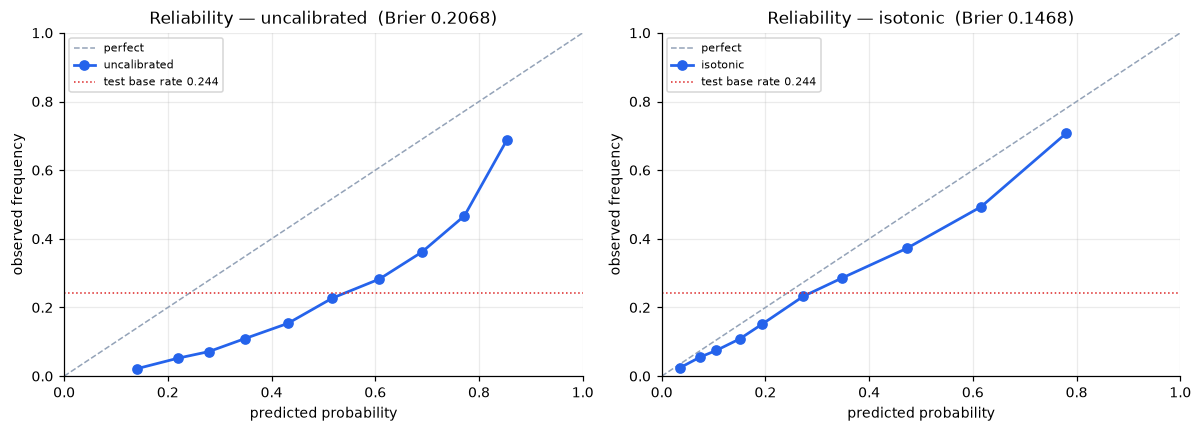

Brier  uncalibrated        : 0.2068
Brier  isotonic            : 0.1468
Brier  constant base rate  : 0.1842   <-- the bar to beat
mean predicted             : 0.2975   vs   actual 0.2436


In [9]:
# Isotonic can map to exactly 0.0 and 1.0. Showing a release manager "100% risk" is
# indefensible for a model with a finite validation set, so clamp to an honest interval.
PROB_CLIP = (1e-3, 1 - 1e-3)

calibrator = IsotonicRegression(out_of_bounds="clip").fit(raw_val, y_val)
cal_test = np.clip(calibrator.predict(raw_test), *PROB_CLIP)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (p, lbl) in zip(axes, [(raw_test, "uncalibrated"), (cal_test, "isotonic")]):
    frac, mean_pred = calibration_curve(y_test, p, n_bins=10, strategy="quantile")
    ax.plot([0, 1], [0, 1], "--", color="#94a3b8", lw=1, label="perfect")
    ax.plot(mean_pred, frac, marker="o", color="#2563eb", lw=1.8, label=lbl)
    ax.axhline(y_test.mean(), color="#dc2626", ls=":", lw=1, label=f"test base rate {y_test.mean():.3f}")
    ax.set_xlabel("predicted probability"); ax.set_ylabel("observed frequency")
    ax.set_title(f"Reliability — {lbl}  (Brier {brier_score_loss(y_test, p):.4f})")
    ax.legend(fontsize=7); ax.set_xlim(0, 1); ax.set_ylim(0, 1)
plt.tight_layout(); plt.show()

const = np.full_like(cal_test, y_test.mean())
print(f"Brier  uncalibrated        : {brier_score_loss(y_test, raw_test):.4f}")
print(f"Brier  isotonic            : {brier_score_loss(y_test, cal_test):.4f}")
print(f"Brier  constant base rate  : {brier_score_loss(y_test, const):.4f}   <-- the bar to beat")
print(f"mean predicted             : {cal_test.mean():.4f}   vs   actual {y_test.mean():.4f}")
if brier_score_loss(y_test, cal_test) > brier_score_loss(y_test, const):
    print("\nWARNING: the model's Brier is worse than predicting the base rate for every PR.")
    print("A Brier score under the PRD's 0.18 target means nothing on its own — check this line.")

## 9. Test evaluation against PRD §1.4 targets

In [10]:
base = y_test.mean()
metrics = {
    "auc_roc":            float(roc_auc_score(y_test, cal_test)),
    "auc_pr":             float(average_precision_score(y_test, cal_test)),
    "auc_pr_baseline":    float(base),
    "brier":              float(brier_score_loss(y_test, cal_test)),
    "brier_constant":     float(brier_score_loss(y_test, const)),
    "n_test":             int(len(y_test)),
    "test_base_rate":     float(base),
}

gains = pd.DataFrame({"y": y_test, "p": cal_test}).sort_values("p", ascending=False).reset_index(drop=True)
gains["decile"] = pd.qcut(np.arange(len(gains)), 10, labels=False, duplicates="drop")
lift = gains.groupby("decile").agg(n=("y", "size"), captured=("y", "sum"), rate=("y", "mean"))
lift["lift"] = lift["rate"] / base
lift["cum_recall"] = lift["captured"].cumsum() / gains.y.sum()
metrics["top_decile_lift"] = float(lift.loc[0, "lift"])
metrics["top_decile_recall"] = float(lift.loc[0, "cum_recall"])

print(f"{'metric':<22}{'value':>10}{'target':>10}  status")
print("-" * 54)
for k, tgt, better_high in [("auc_roc", TARGETS["auc_roc"], True), ("brier", TARGETS["brier"], False)]:
    ok = metrics[k] >= tgt if better_high else metrics[k] <= tgt
    print(f"{k:<22}{metrics[k]:>10.4f}{tgt:>10.2f}  {'PASS' if ok else 'FAIL'}")
print(f"{'auc_pr':<22}{metrics['auc_pr']:>10.4f}{base:>10.4f}  (baseline = base rate)")
print(f"{'top_decile_lift':<22}{metrics['top_decile_lift']:>10.2f}x")
print(f"{'top_decile_recall':<22}{metrics['top_decile_recall']:>10.2%}")

display(lift.style.format({"n": "{:,}", "rate": "{:.3f}", "lift": "{:.2f}x", "cum_recall": "{:.1%}"}))

# Risk-band distribution — what fraction of real PRs each band would flag
bands = pd.cut(cal_test, bins=[0, .30, .60, .85, 1.01],
               labels=["LOW", "MEDIUM", "HIGH", "CRITICAL"], right=False)
band_tbl = pd.DataFrame({"band": bands, "y": y_test}).groupby("band", observed=False).agg(
    n=("y", "size"), actual_buggy_rate=("y", "mean"))
band_tbl["share_of_prs"] = band_tbl["n"] / len(y_test)
print("\nRisk-band behaviour (PRD §5 thresholds) — does each band mean what it claims?")
display(band_tbl.style.format({"n": "{:,}", "actual_buggy_rate": "{:.3f}", "share_of_prs": "{:.1%}"}))

metric                     value    target  status
------------------------------------------------------
auc_roc                   0.8006      0.72  PASS
brier                     0.1468      0.18  PASS
auc_pr                    0.5675    0.2436  (baseline = base rate)
top_decile_lift             2.79x
top_decile_recall         27.96%


,n,captured,rate,lift,cum_recall
decile,,,,,
0,"1,945",1324,0.681,2.79x,28.0%
1,"1,944",920,0.473,1.94x,47.4%
2,"1,945",717,0.369,1.51x,62.5%
3,"1,944",539,0.277,1.14x,73.9%
4,"1,945",444,0.228,0.94x,83.3%
5,"1,944",287,0.148,0.61x,89.3%
6,"1,944",215,0.111,0.45x,93.9%
7,"1,945",146,0.075,0.31x,97.0%
8,"1,944",106,0.055,0.22x,99.2%



Risk-band behaviour (PRD §5 thresholds) — does each band mean what it claims?


,n,actual_buggy_rate,share_of_prs
band,,,
LOW,"12,064",0.110,62.0%
MEDIUM,"3,944",0.342,20.3%
HIGH,"2,992",0.559,15.4%
CRITICAL,445,0.856,2.3%


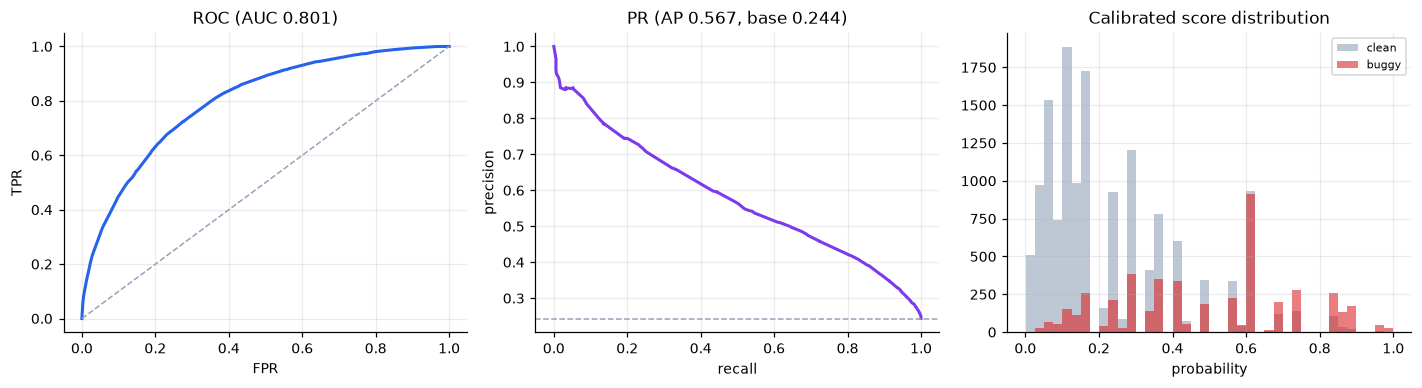

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))

fpr, tpr, _ = roc_curve(y_test, cal_test)
axes[0].plot(fpr, tpr, color="#2563eb", lw=2); axes[0].plot([0, 1], [0, 1], "--", color="#94a3b8", lw=1)
axes[0].set_title(f"ROC (AUC {metrics['auc_roc']:.3f})"); axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR")

prec, rec, _ = precision_recall_curve(y_test, cal_test)
axes[1].plot(rec, prec, color="#7c3aed", lw=2); axes[1].axhline(base, ls="--", color="#94a3b8", lw=1)
axes[1].set_title(f"PR (AP {metrics['auc_pr']:.3f}, base {base:.3f})"); axes[1].set_xlabel("recall"); axes[1].set_ylabel("precision")

axes[2].hist(cal_test[y_test == 0], bins=40, alpha=.6, label="clean", color="#94a3b8")
axes[2].hist(cal_test[y_test == 1], bins=40, alpha=.6, label="buggy", color="#dc2626")
axes[2].set_title("Calibrated score distribution"); axes[2].set_xlabel("probability"); axes[2].legend(fontsize=7)

plt.tight_layout(); plt.show()

## 10. Baseline comparison study

Every metric so far describes the final model in isolation. The first question a judge
without an ML background will ask is *"why not something simpler?"* — this section
answers it with numbers instead of intuition.

Five rows, all scored on the identical held-out `test_df` / `y_test`:

| Baseline | What it represents |
|---|---|
| Constant (train base rate) | The null model — predicts the same number for every commit |
| `fix` alone | The single SZZ-artifact keyword feature excluded from the real model (§5), calibrated with a two-bucket empirical rate |
| Churn-only logistic | "Big changes are risky" — the simplest defensible heuristic a non-ML team would ship, on `log1p(la)` / `log1p(ld)` |
| Full-feature logistic | All 12 canonical features, linear, no interactions — isolates how much of the gain is "more signal" vs "tree ensemble" |
| **XGBoost (this model)** | The calibrated model from §7–§9 |

AUC-ROC and AUC-PR are computed on each baseline's **raw** score — ranking is a
monotone-invariant property, and mixing in a calibrated score understates it (see the
~1.6pt AUC-PR gap between §7's raw test number and §9's calibrated one — that's isotonic's
flat regions introducing ties, not a real ranking change). Brier is computed on a
**calibrated** probability for every baseline that can honestly produce one, so it isn't
comparing an uncalibrated heuristic to a calibrated model.

95% CIs are percentile bootstrap (test-set resampling, default 500 draws) so the deltas
between rows are defensible in front of a judge, not just point-estimate bragging.

In [12]:
# ---------------------------------------------------------------------------
# Bootstrap CI helper — resample the TEST set with replacement, recompute the
# metric each time. Reused for every baseline below and again in §11 for the
# risk bands. Lower N_BOOT if you want this to run faster; 500 is already
# stable enough for a percentile CI at this test-set size (~19k rows).
# ---------------------------------------------------------------------------
N_BOOT = 500
rng = np.random.default_rng(SEED)

def _boot_ci(fn, y_true, *scores, n_boot=N_BOOT, alpha=0.05):
    """Percentile bootstrap CI for fn(y_true, *scores) computed on resampled test rows."""
    n = len(y_true)
    vals = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        yb = y_true[idx]
        if yb.sum() == 0 or yb.sum() == n:      # degenerate resample, skip
            continue
        vals.append(fn(yb, *[s[idx] for s in scores]))
    lo, hi = np.percentile(vals, [100 * alpha / 2, 100 * (1 - alpha / 2)])
    return float(lo), float(hi)

def evaluate_baseline(name, y_true, rank_score, prob_score=None):
    """rank_score: any monotone risk score, used for AUC-ROC / AUC-PR.
       prob_score: a calibrated-ish probability, used for Brier. None if the
       baseline can't honestly produce one (it will show as n/a, not a free pass)."""
    auc = roc_auc_score(y_true, rank_score)
    ap  = average_precision_score(y_true, rank_score)
    auc_lo, auc_hi = _boot_ci(roc_auc_score, y_true, rank_score)
    ap_lo,  ap_hi  = _boot_ci(average_precision_score, y_true, rank_score)
    row = dict(baseline=name, auc_roc=auc, auc_roc_lo=auc_lo, auc_roc_hi=auc_hi,
               auc_pr=ap, auc_pr_lo=ap_lo, auc_pr_hi=ap_hi)
    if prob_score is not None:
        br = brier_score_loss(y_true, prob_score)
        br_lo, br_hi = _boot_ci(brier_score_loss, y_true, prob_score)
    else:
        br = br_lo = br_hi = float("nan")
    row.update(brier=br, brier_lo=br_lo, brier_hi=br_hi)
    return row

print(f"bootstrap CIs will use {N_BOOT} resamples of the {len(y_test):,}-row test set")

bootstrap CIs will use 500 resamples of the 19,445-row test set


In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

def _log1p_cols(d, cols):
    return np.log1p(d[list(cols)].values.astype(float))

# ---- 1. Constant baseline: train base rate for every commit ----
prob_const = np.full(len(y_test), y_train.mean(), dtype=float)
rank_const = prob_const

# ---- 2. `fix` alone, calibrated as a two-bucket empirical rate fit on TRAIN ----
p_fix1 = train_df.loc[train_df.fix == 1, "buggy"].mean()
p_fix0 = train_df.loc[train_df.fix == 0, "buggy"].mean()
fix_test = test_df["fix"].values
prob_fix = np.where(fix_test == 1, p_fix1, p_fix0)
rank_fix = fix_test.astype(float)

# ---- 3. Churn-only logistic: log1p(la), log1p(ld) -> isotonic-calibrated, same as the real model ----
churn_cols = ["la", "ld"]
Xtr_churn, Xval_churn, Xtest_churn = (_log1p_cols(d, churn_cols) for d in (train_df, val_df, test_df))
scaler_churn = StandardScaler().fit(Xtr_churn)
lr_churn = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=SEED)
lr_churn.fit(scaler_churn.transform(Xtr_churn), y_train)
raw_churn_val  = lr_churn.predict_proba(scaler_churn.transform(Xval_churn))[:, 1]
raw_churn_test = lr_churn.predict_proba(scaler_churn.transform(Xtest_churn))[:, 1]
cal_churn_fit = IsotonicRegression(out_of_bounds="clip").fit(raw_churn_val, y_val)
prob_churn = np.clip(cal_churn_fit.predict(raw_churn_test), *PROB_CLIP)
rank_churn = raw_churn_test

# ---- 4. Full-feature logistic: all 12 canonical features, same log1p + isotonic treatment ----
Xtr_full, Xval_full, Xtest_full = (_log1p_cols(d, CANONICAL) for d in (train_df, val_df, test_df))
scaler_full = StandardScaler().fit(Xtr_full)
lr_full = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=SEED)
lr_full.fit(scaler_full.transform(Xtr_full), y_train)
raw_full_val  = lr_full.predict_proba(scaler_full.transform(Xval_full))[:, 1]
raw_full_test = lr_full.predict_proba(scaler_full.transform(Xtest_full))[:, 1]
cal_full_fit = IsotonicRegression(out_of_bounds="clip").fit(raw_full_val, y_val)
prob_full = np.clip(cal_full_fit.predict(raw_full_test), *PROB_CLIP)
rank_full = raw_full_test

# ---- 5. XGBoost (this model) — reuse §7/§8 outputs, no refitting ----
rank_xgb, prob_xgb = raw_test, cal_test

baseline_rows = [
    evaluate_baseline("Constant (base rate)",        y_test, rank_const, prob_const),
    evaluate_baseline("`fix` alone",                 y_test, rank_fix,   prob_fix),
    evaluate_baseline("Churn-only logistic (la+ld)", y_test, rank_churn, prob_churn),
    evaluate_baseline("Full-feature logistic",       y_test, rank_full,  prob_full),
    evaluate_baseline("XGBoost (this model)",        y_test, rank_xgb,   prob_xgb),
]
baseline_df = pd.DataFrame(baseline_rows)

display_cols = ["baseline", "auc_roc", "auc_roc_lo", "auc_roc_hi",
                "auc_pr", "auc_pr_lo", "auc_pr_hi", "brier", "brier_lo", "brier_hi"]
fmt = {c: "{:.4f}" for c in display_cols if c != "baseline"}
display(baseline_df[display_cols].style.format(fmt).hide(axis="index"))

xgb_ap = baseline_df.iloc[-1]["auc_pr"]
best_simple_row = baseline_df.iloc[1:4].loc[baseline_df.iloc[1:4]["auc_pr"].idxmax()]
print(f"\nXGBoost AUC-PR {xgb_ap:.4f}  vs strongest simple baseline "
      f"({best_simple_row['baseline']}) {best_simple_row['auc_pr']:.4f}"
      f"   (+{xgb_ap - best_simple_row['auc_pr']:.4f})")
print(f"XGBoost AUC-PR {xgb_ap:.4f}  vs constant/base-rate {baseline_df.iloc[0]['auc_pr']:.4f}"
      f"   (+{xgb_ap - baseline_df.iloc[0]['auc_pr']:.4f})")
if xgb_ap - best_simple_row["auc_pr"] < 0.02:
    print("\nNOTE: the gap over the strongest simple baseline is small. Decide with this")
    print("number in front of you whether the ensemble complexity is earning its keep.")

baseline,auc_roc,auc_roc_lo,auc_roc_hi,auc_pr,auc_pr_lo,auc_pr_hi,brier,brier_lo,brier_hi
Constant (base rate),0.5000,0.5000,0.5000,0.2436,0.2371,0.2497,0.1867,0.1841,0.1891
`fix` alone,0.6277,0.6210,0.6339,0.3743,0.3638,0.3866,0.1643,0.1616,0.1672
Churn-only logistic (la+ld),0.7855,0.7779,0.7927,0.5464,0.5311,0.5618,0.1504,0.1479,0.1529
Full-feature logistic,0.7908,0.7839,0.7978,0.5587,0.5424,0.5740,0.1484,0.1458,0.1512
XGBoost (this model),0.8012,0.7943,0.8080,0.5792,0.5645,0.5938,0.1468,0.1440,0.1496



XGBoost AUC-PR 0.5792  vs strongest simple baseline (Full-feature logistic) 0.5587   (+0.0205)
XGBoost AUC-PR 0.5792  vs constant/base-rate 0.2436   (+0.3356)


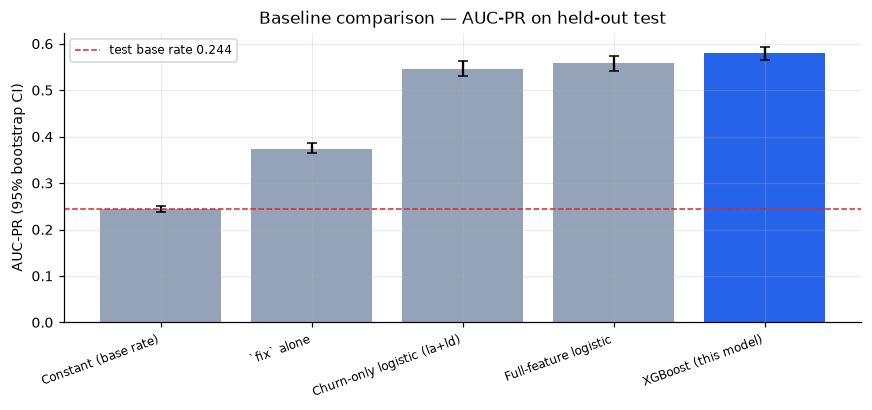

In [14]:
fig, ax = plt.subplots(figsize=(8, 3.8))
x = np.arange(len(baseline_df))
yerr = np.vstack([baseline_df["auc_pr"] - baseline_df["auc_pr_lo"],
                  baseline_df["auc_pr_hi"] - baseline_df["auc_pr"]])
colors = ["#94a3b8", "#94a3b8", "#94a3b8", "#94a3b8", "#2563eb"]
ax.bar(x, baseline_df["auc_pr"], yerr=yerr, capsize=3, color=colors)
ax.axhline(y_test.mean(), ls="--", color="#dc2626", lw=1, label=f"test base rate {y_test.mean():.3f}")
ax.set_xticks(x); ax.set_xticklabels(baseline_df["baseline"], rotation=20, ha="right", fontsize=8)
ax.set_ylabel("AUC-PR (95% bootstrap CI)")
ax.set_title("Baseline comparison — AUC-PR on held-out test")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 11. Risk threshold calibration

`RISK_THRESHOLDS` in §0 (0.30 / 0.60 / 0.85) come from the PRD, not from this data. §9
already checks whether the resulting bands separate; this section goes three steps further:

1. Confirms separation with **bootstrap CIs per band**, not just a point estimate — a
   band built from a few hundred test PRs can look separated by chance.
2. Checks **band population sizes** — a band nobody's PR ever lands in isn't doing
   product work no matter how correct it looks.
3. Derives an **alternative, quantile-based** set of cutoffs from the calibrated score's
   own distribution, as a second reference point besides "the PRD said so."
4. Builds a **cost-sensitivity curve**: given an assumed ratio between the cost of a
   missed bug (false negative) and the cost of an unnecessary review (false positive),
   shows where the break-even MEDIUM/HIGH cutoff actually sits. This is what answers
   "why 0.60?" with a reason instead of a citation.

In [15]:
# Reuses `bands` from §9 (PRD thresholds 0.30 / 0.60 / 0.85) — checks whether the
# separation shown there survives a confidence interval and a minimum sample size.
def bootstrap_rate_ci(y, n_boot=N_BOOT, alpha=0.05):
    n = len(y)
    if n < 10:
        return float("nan"), float("nan")
    vals = [y[rng.integers(0, n, size=n)].mean() for _ in range(n_boot)]
    return float(np.percentile(vals, 100 * alpha / 2)), float(np.percentile(vals, 100 * (1 - alpha / 2)))

rows = []
for b in ["LOW", "MEDIUM", "HIGH", "CRITICAL"]:
    mask = (bands == b).values if hasattr(bands == b, "values") else (bands == b)
    yb = y_test[np.asarray(mask)]
    n = int(np.asarray(mask).sum())
    rate = float(yb.mean()) if n else float("nan")
    lo, hi = bootstrap_rate_ci(yb)
    rows.append(dict(band=b, n=n, share=n / len(y_test), actual_buggy_rate=rate, ci_lo=lo, ci_hi=hi))
band_ci = pd.DataFrame(rows)
display(band_ci.style.format({"n": "{:,}", "share": "{:.1%}", "actual_buggy_rate": "{:.3f}",
                              "ci_lo": "{:.3f}", "ci_hi": "{:.3f}"}).hide(axis="index"))

rates = band_ci["actual_buggy_rate"].values
monotonic = all((a <= b) for a, b in zip(rates, rates[1:]) if not (np.isnan(a) or np.isnan(b)))
status = "YES" if monotonic else "NO -- thresholds need moving, not the model"
print(f"monotonic increasing LOW -> CRITICAL: {status}")

thin = band_ci[band_ci["n"] < 30]
if len(thin):
    thin_bands = list(thin["band"])
    print(f"WARNING: band(s) with <30 test PRs -- rate estimate is not demo-safe: {thin_bands}")
else:
    print("all bands have >=30 test PRs -- rate estimates are demo-safe")

band,n,share,actual_buggy_rate,ci_lo,ci_hi
LOW,"12,064",62.0%,0.110,0.105,0.117
MEDIUM,"3,944",20.3%,0.342,0.327,0.355
HIGH,"2,992",15.4%,0.559,0.541,0.578
CRITICAL,445,2.3%,0.856,0.825,0.890


monotonic increasing LOW -> CRITICAL: YES
all bands have >=30 test PRs -- rate estimates are demo-safe


In [16]:
# Alternative: cutoffs by quantile of the calibrated score. Guarantees non-degenerate
# band sizes -- useful to check whether the PRD's fixed probabilities are quietly
# starving CRITICAL of any real PRs.
QUANTILE_CUTS = [0.50, 0.80, 0.95]   # population share at each LOW/MED/HIGH/CRIT boundary

q_thresholds = np.quantile(cal_test, QUANTILE_CUTS)
q_thresholds = np.maximum.accumulate(q_thresholds)                        # guard against isotonic plateaus
q_thresholds = q_thresholds + np.arange(len(q_thresholds)) * 1e-6         # break exact ties for pd.cut

print("PRD thresholds       LOW/MED 0.30   MED/HIGH 0.60   HIGH/CRIT 0.85")
print(f"Quantile thresholds  LOW/MED {q_thresholds[0]:.3f}   MED/HIGH {q_thresholds[1]:.3f}   "
      f"HIGH/CRIT {q_thresholds[2]:.3f}")

bands_q = pd.cut(cal_test, bins=[0, *q_thresholds, 1.001],
                 labels=["LOW", "MEDIUM", "HIGH", "CRITICAL"], right=False)
band_q_tbl = pd.DataFrame({"band": bands_q, "y": y_test}).groupby("band", observed=False).agg(
    n=("y", "size"), actual_buggy_rate=("y", "mean"))
band_q_tbl["share_of_prs"] = band_q_tbl["n"] / len(y_test)
display(band_q_tbl.style.format({"n": "{:,}", "actual_buggy_rate": "{:.3f}", "share_of_prs": "{:.1%}"}))

PRD thresholds       LOW/MED 0.30   MED/HIGH 0.60   HIGH/CRIT 0.85
Quantile thresholds  LOW/MED 0.233   MED/HIGH 0.555   HIGH/CRIT 0.727


,n,actual_buggy_rate,share_of_prs
band,,,
LOW,"9,654",0.081,49.6%
MEDIUM,"6,263",0.296,32.2%
HIGH,"2,705",0.539,13.9%
CRITICAL,823,0.785,4.2%


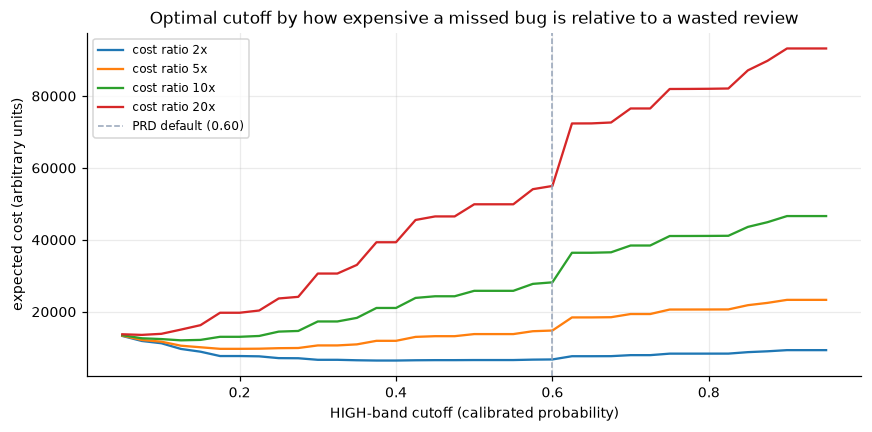

Optimal cutoff by assumed cost ratio (missed-bug : unnecessary-review):
    2x  ->  cutoff 0.37   (PRD default: 0.60)
    5x  ->  cutoff 0.17   (PRD default: 0.60)
   10x  ->  cutoff 0.12   (PRD default: 0.60)
   20x  ->  cutoff 0.07   (PRD default: 0.60)


In [17]:
# Cost-sensitivity: sweep the MEDIUM/HIGH cutoff and compute expected cost per PR at
# several assumed cost ratios (cost of a missed bug in prod / cost of one unnecessary
# extra review). This is the honest answer to "why 0.60?" instead of "the PRD said so."
cutoffs = np.linspace(0.05, 0.95, 37)
cost_ratios = [2, 5, 10, 20]   # a missed bug costs N x an unnecessary review

def expected_cost(cutoff, ratio):
    flagged = cal_test >= cutoff
    fn = int(((~flagged) & (y_test == 1)).sum())     # missed bugs
    fp = int((flagged & (y_test == 0)).sum())        # unnecessary reviews
    return ratio * fn + fp

fig, ax = plt.subplots(figsize=(8, 4))
best_cutoffs = {}
for ratio in cost_ratios:
    costs = [expected_cost(c, ratio) for c in cutoffs]
    ax.plot(cutoffs, costs, label=f"cost ratio {ratio}x")
    best_cutoffs[ratio] = float(cutoffs[int(np.argmin(costs))])
ax.axvline(0.60, ls="--", color="#94a3b8", lw=1, label="PRD default (0.60)")
ax.set_xlabel("HIGH-band cutoff (calibrated probability)")
ax.set_ylabel("expected cost (arbitrary units)")
ax.set_title("Optimal cutoff by how expensive a missed bug is relative to a wasted review")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

print("Optimal cutoff by assumed cost ratio (missed-bug : unnecessary-review):")
for ratio, cutoff in best_cutoffs.items():
    print(f"  {ratio:>3}x  ->  cutoff {cutoff:.2f}   (PRD default: 0.60)")

### What to look at

- If `monotonic` above is `NO`, or any band has fewer than 30 test PRs, the PRD's fixed
  thresholds aren't supported by this data yet -- that's a finding worth stating out loud
  in the pitch, not something to quietly re-run until it looks better.
- Compare the quantile thresholds to the PRD ones. Close together -> the PRD numbers are
  basically already quantile-sane and you can defend them as-is. Far apart (e.g. the
  quantile HIGH/CRIT cutoff sits well below 0.85) -> CRITICAL is likely near-empty in
  practice, which is worth flagging before a judge finds it in the band table.
- The cost-sensitivity plot is the slide for "why 0.60 and not 0.5 or 0.7?" -- the honest
  answer becomes "because at a cost ratio of roughly N x, expected cost is minimized
  there," not "the spec said so." If the optimal cutoff barely moves across plausible
  ratios, that's a strong result; if it swings a lot, say so and pick the ratio you can
  actually justify (e.g. from typical PR review time vs. incident cost, if you have it).

## 12. SHAP (PRD Module 6)

`TreeExplainer`, exact for tree ensembles. Explains the **raw margin (log-odds)** — SHAP
values are additive there and are *not* additive on the calibrated output. The additivity
assertion below is the same check PRD Module 6 requires as a test.

No matplotlib is rendered server-side in production; the serialiser emits the exact JSON
shape Module 6 specifies for the Recharts/D3 frontend.

additivity max error: 1.67e-06  OK


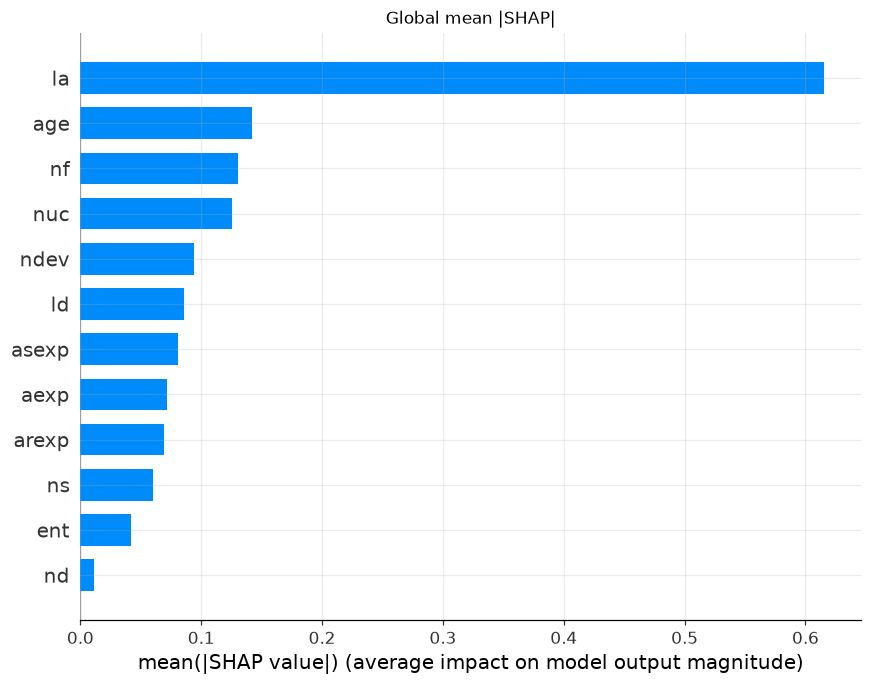

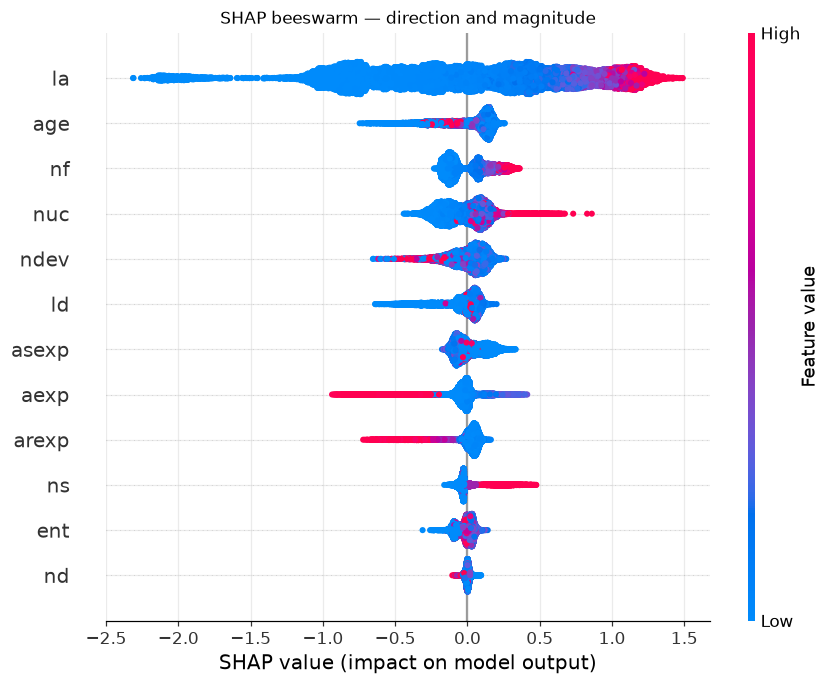

In [18]:
explainer = shap.TreeExplainer(booster)     # the TRUNCATED booster, not the wrapper
sv_test = explainer.shap_values(X_test)

# Module 6 test: base_value + sum(shap) == raw margin.
# This only holds if SHAP and the scorer see the same trees — hence the truncation in §7.
margin = raw_margin(X_test)
recon = explainer.expected_value + sv_test.sum(axis=1)
max_err = float(np.abs(recon - margin).max())
print(f"additivity max error: {max_err:.2e}  {'OK' if max_err < 1e-4 else 'FAIL'}")

shap.summary_plot(sv_test, test_df[list(FEATURE_ORDER)], plot_type="bar", show=False, max_display=len(FEATURE_ORDER))
plt.title("Global mean |SHAP|"); plt.tight_layout(); plt.show()

shap.summary_plot(sv_test, test_df[list(FEATURE_ORDER)], show=False, max_display=len(FEATURE_ORDER))
plt.title("SHAP beeswarm — direction and magnitude"); plt.tight_layout(); plt.show()

highest-risk test commit: p=0.999  actual=BUGGY
{
  "base_value": 0.0033240411430597305,
  "output_value": 0.9990000128746033,
  "contributions": [
    {
      "feature_name": "la",
      "display_name": "Lines Added",
      "raw_value": 467.0,
      "shap_value": 1.0345109701156616,
      "direction": "increases_risk",
      "rank": 1
    },
    {
      "feature_name": "ns",
      "display_name": "Subsystems Changed",
      "raw_value": 5.0,
      "shap_value": 0.3052043914794922,
      "direction": "increases_risk",
      "rank": 2
    },
    {
      "feature_name": "nf",
      "display_name": "Files Changed",
      "raw_value": 22.0,
      "shap_value": 0.2752739191055298,
      "direction": "increases_risk",
      "rank": 3
    },
    {
      "feature_name": "age",
      "display_name": "File Age (days)",
      "raw_value": 34.0909090909091,
      "shap_value": 0.1726868599653244,
      "direction": "increases_risk",
      "rank":


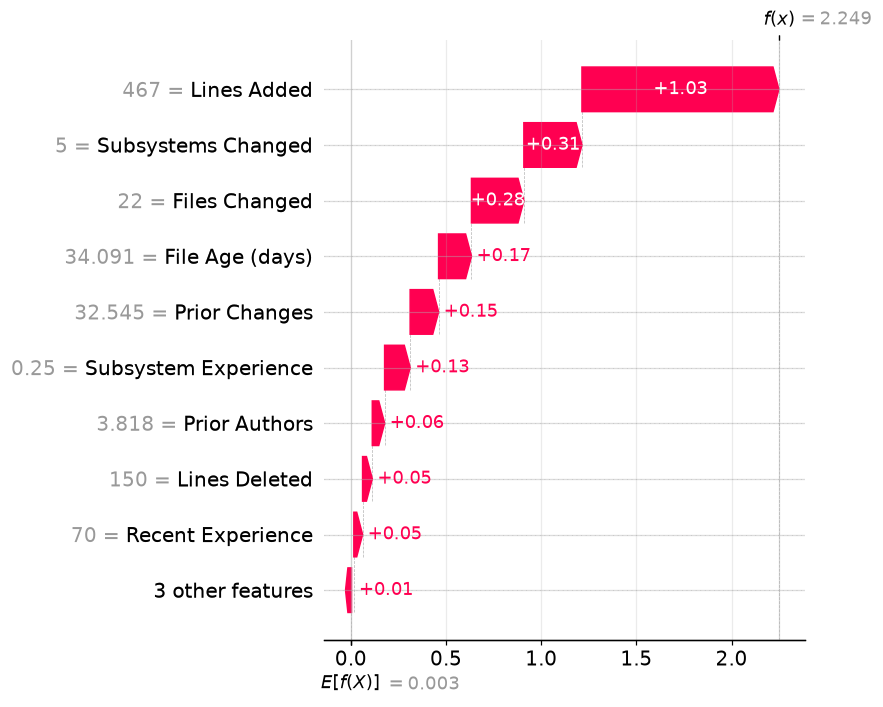

In [19]:
def serialize_shap(row_idx: int) -> dict:
    # Emit the exact JSON contract from PRD Module 6.
    vals = sv_test[row_idx]
    raw_feats = X_test[row_idx]
    base_value = float(explainer.expected_value)

    contribs = [
        dict(feature_name=f,
             display_name=FEATURE_METADATA[f]["display_name"],
             raw_value=float(raw_feats[i]),
             shap_value=float(vals[i]),
             direction="increases_risk" if vals[i] > 0 else "decreases_risk")
        for i, f in enumerate(FEATURE_ORDER)
    ]
    contribs.sort(key=lambda c: abs(c["shap_value"]), reverse=True)
    for r, c in enumerate(contribs, 1):
        c["rank"] = r

    steps, cum = [dict(label="Base", value=base_value, cumulative=base_value)], base_value
    for c in contribs:
        cum += c["shap_value"]
        steps.append(dict(label=c["display_name"], value=c["shap_value"], cumulative=cum))

    return dict(base_value=base_value,
                output_value=float(cal_test[row_idx]),
                contributions=contribs,
                waterfall_data=dict(steps=steps, final=float(cal_test[row_idx])))

example = int(np.argmax(cal_test))   # highest-risk PR in the test set
payload = serialize_shap(example)
print(f"highest-risk test commit: p={payload['output_value']:.3f}  actual={'BUGGY' if y_test[example] else 'clean'}")
print(json.dumps({**payload, "waterfall_data": "...truncated..."}, indent=2)[:900])

shap.plots.waterfall(
    shap.Explanation(values=sv_test[example],
                     base_values=float(explainer.expected_value),
                     data=X_test[example],
                     feature_names=[FEATURE_METADATA[f]["display_name"] for f in FEATURE_ORDER]),
    show=False)
plt.tight_layout(); plt.show()

## 13. Export artifacts

Writes the four files PRD Module 5 step 8 requires. `feature_schema_v1.json` is the one
that prevents the catastrophic bug — Module 3's extractor and Module 5's `ModelLoader`
both validate against it at startup, so a feature-order or entropy-definition drift
fails fast instead of silently producing wrong scores.

In [20]:
booster.save_model(OUTPUT_DIR / f"xgboost_jit_{MODEL_VERSION}.json")   # truncated
joblib.dump(calibrator, OUTPUT_DIR / f"calibrator_{MODEL_VERSION}.pkl")

schema = {
    "model_version": MODEL_VERSION,
    "feature_order": list(FEATURE_ORDER),
    "n_features": len(FEATURE_ORDER),
    "feature_metadata": {f: FEATURE_METADATA[f] for f in FEATURE_ORDER},
    "entropy_spec": ENTROPY_SPEC,
    "excluded_features": {
        "lt": "Not present in ApacheJIT. Remove from Module 3 extractor output.",
        **({} if INCLUDE_FIX else {"fix": "Excluded — SZZ label artifact. Compute and display as context, never feed to the model."}),
    },
    "naming_map": {"exp": "aexp", "rexp": "arexp", "sexp": "asexp"},
    "transform": "identity (tree splits are invariant under monotone transforms; log1p is a no-op here)",
    "training": {
        "dataset": "ApacheJIT (Keshavarz & Nagappan, MSR 2022)",
        "split_strategy": SPLIT_STRATEGY,
        "seed": SEED,
        "scale_pos_weight": float(SCALE_POS_WEIGHT),
        "hyperparameters": BEST_PARAMS,
        "best_iteration": int(model.best_iteration),
        "n_trees_saved": BEST_NTREE,
        "calibration": "isotonic, fitted on validation split",
        "probability_clip": list(PROB_CLIP),
        "inference_note": ("Artifact is already truncated to best_iteration. Load with "
                           "xgb.Booster().load_model() and call predict() with no "
                           "iteration_range — all saved trees are intended."),
    },
    "risk_thresholds": {k: list(v) for k, v in RISK_THRESHOLDS.items()},
    "created_at": datetime.now(timezone.utc).isoformat(),
}
(OUTPUT_DIR / f"feature_schema_{MODEL_VERSION}.json").write_text(json.dumps(schema, indent=2))

metrics_out = {**metrics,
               "model_version": MODEL_VERSION,
               "split_strategy": SPLIT_STRATEGY,
               "include_fix": INCLUDE_FIX,
               "n_train": int(len(y_train)), "n_val": int(len(y_val)),
               "train_base_rate": float(y_train.mean()), "val_base_rate": float(y_val.mean()),
               "shap_additivity_max_error": max_err,
               "targets": TARGETS,
               "passes_auc_target": bool(metrics["auc_roc"] >= TARGETS["auc_roc"]),
               "passes_brier_target": bool(metrics["brier"] <= TARGETS["brier"]),
               "beats_constant_baseline": bool(metrics["brier"] < metrics["brier_constant"]),
               "created_at": datetime.now(timezone.utc).isoformat()}
(OUTPUT_DIR / "metrics.json").write_text(json.dumps(metrics_out, indent=2))

for p in sorted(OUTPUT_DIR.iterdir()):
    print(f"  {p.name:34s} {p.stat().st_size:>9,} bytes")

  calibrator_v1.pkl                      1,279 bytes
  feature_schema_v1.json                 4,617 bytes
  metrics.json                             786 bytes
  xgboost_jit_v1.json                4,411,530 bytes


## 14. Model card

PRD §12 requires `docs/model_card.md` generated from `metrics.json`. This writes the
honest version — including the limitations, because a card that omits them is worse than
no card when a judge or an auditor reads it.

In [21]:
card = f'''# Model Card — Deployment Risk Scorer {MODEL_VERSION}

## Overview
XGBoost binary classifier estimating the probability that a change introduces a defect,
trained on ApacheJIT and calibrated with isotonic regression.

- **Trained** {datetime.now(timezone.utc).date()}
- **Dataset** ApacheJIT (Keshavarz & Nagappan, MSR 2022) — {len(df):,} commits, {df.project.nunique()} Apache projects, {df.dt.min().date()}–{df.dt.max().date()}
- **Split** `{SPLIT_STRATEGY}` (temporal) — train {len(y_train):,} / val {len(y_val):,} / test {len(y_test):,}
- **Features** {len(FEATURE_ORDER)} — {', '.join(FEATURE_ORDER)}

## Performance (held-out test)
| Metric | Value | PRD target |
|---|---|---|
| AUC-ROC | {metrics['auc_roc']:.4f} | ≥ 0.72 |
| AUC-PR | {metrics['auc_pr']:.4f} | baseline {metrics['auc_pr_baseline']:.4f} |
| Brier | {metrics['brier']:.4f} | ≤ 0.18 |
| Brier (constant base rate) | {metrics['brier_constant']:.4f} | reference |
| Top-decile lift | {metrics['top_decile_lift']:.2f}x | — |
| Top-decile recall | {metrics['top_decile_recall']:.1%} | — |

## Limitations — read before trusting a score

1. **Labels are SZZ-derived defect labels, not production incidents.** The model predicts
   "a later bugfix will touch lines this change introduced." It does not predict outages,
   rollbacks, or SLO breaches. Any claim that this is incident prediction rather than
   just-in-time defect prediction is unsupported by the training data.
2. **Training domain is Apache OSS Java projects.** Transfer to a different language,
   review culture, or repository size is unvalidated.
3. **`lt` is unavailable** in ApacheJIT, so the canonical Kamei feature set is
   incomplete by one feature.
4. **`fix` is {'included — see the ablation in §5, it is an SZZ construction artifact and its SHAP attribution is not causally meaningful' if INCLUDE_FIX else 'excluded'}.**
5. **Entropy is raw, not normalised.** The extractor must match `entropy_spec` in
   `feature_schema_{MODEL_VERSION}.json` exactly.
6. **History features are approximations at inference.** PRD Module 3 samples ≤20 files
   and ≤50 commits per file, then extrapolates. ApacheJIT computed them over full history.
   This is a training/serving distribution gap that is not corrected for.
7. **Label maturity.** Recent commits are systematically under-labelled. {'The 2019 tail is excluded from this split.' if SPLIT_STRATEGY == 'mature' else 'This split includes the immature 2019 tail in test; calibration will not transfer.'}

## Intended use
Advisory ranking of changes by relative defect risk. Not an auto-merge gate, not a
security control, not a substitute for review or CI.
'''
Path("model_card.md").write_text(card)
print(card)

# Model Card — Deployment Risk Scorer v1

## Overview
XGBoost binary classifier estimating the probability that a change introduces a defect,
trained on ApacheJIT and calibrated with isotonic regression.

- **Trained** 2026-07-29
- **Dataset** ApacheJIT (Keshavarz & Nagappan, MSR 2022) — 106,674 commits, 15 Apache projects, 2003-09-11–2019-12-26
- **Split** `mature` (temporal) — train 66,144 / val 10,688 / test 19,445
- **Features** 12 — ns, nd, nf, ent, la, ld, ndev, age, nuc, aexp, arexp, asexp

## Performance (held-out test)
| Metric | Value | PRD target |
|---|---|---|
| AUC-ROC | 0.8006 | ≥ 0.72 |
| AUC-PR | 0.5675 | baseline 0.2436 |
| Brier | 0.1468 | ≤ 0.18 |
| Brier (constant base rate) | 0.1842 | reference |
| Top-decile lift | 2.79x | — |
| Top-decile recall | 28.0% | — |

## Limitations — read before trusting a score

1. **Labels are SZZ-derived defect labels, not production incidents.** The model predicts
   "a later bugfix will touch lines this change introduced." It does

---

## What to look at when you run it

1. **§5 ablation** — the AUC-PR gap between with/without `fix` is the price of an
   honest model. Decide with the number in front of you, not in the abstract.
2. **§8 reliability diagram** — if the isotonic curve sits above the diagonal, the model
   is overconfident and the probability shown to a user is a lie. This is the plot that
   determines whether the calibration claim in your pitch holds.
3. **§9 risk-band table** — the HIGH band should contain changes that actually fail more
   often than the MEDIUM band. If the bands don't separate, the PRD thresholds need
   moving, not the model.
4. **§9 top-decile lift** — the number a release manager cares about: how much better
   than random is the top 10% of flagged changes.

## Then re-run once with `SPLIT_STRATEGY = "prd"`

Compare. The PRD split will show a *better-looking* Brier and a similar AUC while being
meaningfully worse calibrated, because its test base rate is 8.3%. Having both numbers is
what lets you answer "why did you deviate from the spec?" with evidence.